# Foraging Grid World Environment
Defines three variants of increasing difficulty used by both REINFORCE
and PPO. Run this notebook first, then import from `env.py`.

| Variant | Grid | Food | Transitions |
|---------|------|------|-------------|
| V1 Easy | 10x10 | 10 | Deterministic |
| V2 Medium | 20x20 | 20 | Deterministic |
| V3 Hard | 20x20 | 20 | Stochastic (ε=0.1) |

In [6]:
import numpy as np
import matplotlib.pyplot as plt

## Environment Class

In [ ]:
class ForagingEnv:
    """
    MDP: M = (S, A, T, R, gamma)

    S: Flattened (2*vision_radius+1)^2 local window.
       Cell values: 0=empty, 1=food, 2=wall, normalised to [0,1].
    A: {0=up, 1=down, 2=left, 3=right}
    T: Deterministic by default. With action_noise_eps > 0 (V3),
       a uniformly random action is executed with probability eps.
    R: +1.0 food, -0.5 wall collision, -0.01 per timestep.
    Episodes terminate after max_steps timesteps.
    Food respawns at a random empty cell after consumption.
    """

    EMPTY = 0
    FOOD = 1

    VARIANTS = {
        "V1": dict(grid_size=10, n_food=10,  max_steps=500,
                   action_noise_eps=0.0),
        "V2": dict(grid_size=20, n_food=20,  max_steps=500,
                   action_noise_eps=0.0),
        "V3": dict(grid_size=20, n_food=20,  max_steps=500,
                   action_noise_eps=0.1),
    }

    def __init__(self, grid_size=20, n_food=20, max_steps=500,
                 vision_radius=2, action_noise_eps=0.0,
                 food_respawn=True, seed=None):
        self.grid_size = grid_size
        self.n_food = n_food
        self.max_steps = max_steps
        self.vision_radius = vision_radius
        self.action_noise_eps = action_noise_eps   # V3 stochasticity
        self.food_respawn = food_respawn
        self.rng = np.random.default_rng(seed)

        self.obs_size = (2 * vision_radius + 1) ** 2
        self.n_actions = 4
        self._action_map = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

        self.reset()

    @classmethod
    def make(cls, variant, seed=None, vision_radius=2):
        """Convenience constructor: ForagingEnv.make('V1', seed=0)"""
        cfg = cls.VARIANTS[variant].copy()
        return cls(**cfg, vision_radius=vision_radius, seed=seed)

    def reset(self):
        self.grid = np.zeros((self.grid_size, self.grid_size),
                             dtype=np.int32)
        self.steps = 0
        self.total_food_eaten = 0
        self.agent_pos = self._random_empty_cell()
        self.food_positions = set()
        while len(self.food_positions) < self.n_food:
            pos = tuple(self._random_empty_cell())
            if pos != tuple(self.agent_pos):
                self.food_positions.add(pos)
                self.grid[pos] = self.FOOD
        return self._get_obs()

    def step(self, action):
        # Stochastic transitions (V3): override action with probability eps
        if self.action_noise_eps > 0:
            if self.rng.random() < self.action_noise_eps:
                action = self.rng.integers(0, self.n_actions)

        dr, dc = self._action_map[action]
        new_r = self.agent_pos[0] + dr
        new_c = self.agent_pos[1] + dc
        reward = -0.01

        if not (0 <= new_r < self.grid_size and 0 <= new_c < self.grid_size):
            reward -= 0.5
        else:
            self.agent_pos = [new_r, new_c]
            pos = tuple(self.agent_pos)
            if pos in self.food_positions:
                reward += 1.0
                self.total_food_eaten += 1
                self.food_positions.remove(pos)
                self.grid[pos] = self.EMPTY
                if self.food_respawn:
                    self._spawn_food()

        self.steps += 1
        done = self.steps >= self.max_steps
        return self._get_obs(), reward, done, \
            {"food_eaten": self.total_food_eaten}

    def _get_obs(self):
        r, c = self.agent_pos
        radius = self.vision_radius
        window = np.full((2*radius+1, 2*radius+1), 2, dtype=np.float32)
        for dr in range(-radius, radius+1):
            for dc in range(-radius, radius+1):
                nr, nc = r+dr, c+dc
                if 0 <= nr < self.grid_size and 0 <= nc < self.grid_size:
                    val = self.FOOD if (nr, nc) in self.food_positions \
                        else self.EMPTY
                    window[dr+radius, dc+radius] = val
        return window.flatten() / 2.0

    def _random_empty_cell(self):
        while True:
            r = self.rng.integers(0, self.grid_size)
            c = self.rng.integers(0, self.grid_size)
            if self.grid[r, c] == self.EMPTY:
                return [r, c]

    def _spawn_food(self):
        for _ in range(1000):
            r, c = self.rng.integers(0, self.grid_size, size=2)
            pos = (int(r), int(c))
            if pos not in self.food_positions and \
               pos != tuple(self.agent_pos):
                self.food_positions.add(pos)
                self.grid[pos] = self.FOOD
                return

    def render(self, ax=None):
        show = ax is None
        if ax is None:
            _, ax = plt.subplots(figsize=(4, 4))
        img = np.zeros((self.grid_size, self.grid_size, 3))
        for (r, c) in self.food_positions:
            img[r, c] = [0.2, 0.8, 0.2]
        r, c = self.agent_pos
        img[r, c] = [0.9, 0.1, 0.1]
        ax.imshow(img, origin="upper")
        ax.set_title(f"t={self.steps} | eaten={self.total_food_eaten}",
                     fontsize=8)
        ax.axis("off")
        if show:
            plt.tight_layout()
            plt.show()

## Smoke Test

In [8]:
for name in ["V1", "V2", "V3"]:
    env = ForagingEnv.make(name, seed=42)
    obs = env.reset()
    done = False
    while not done:
        obs, _, done, info = env.step(np.random.randint(0, 4))
    print(f"{name} | obs_size={env.obs_size} | "
          f"food_eaten={info['food_eaten']} (random policy)")

V1 | obs_size=25 | food_eaten=17 (random policy)
V2 | obs_size=25 | food_eaten=8 (random policy)
V3 | obs_size=25 | food_eaten=9 (random policy)


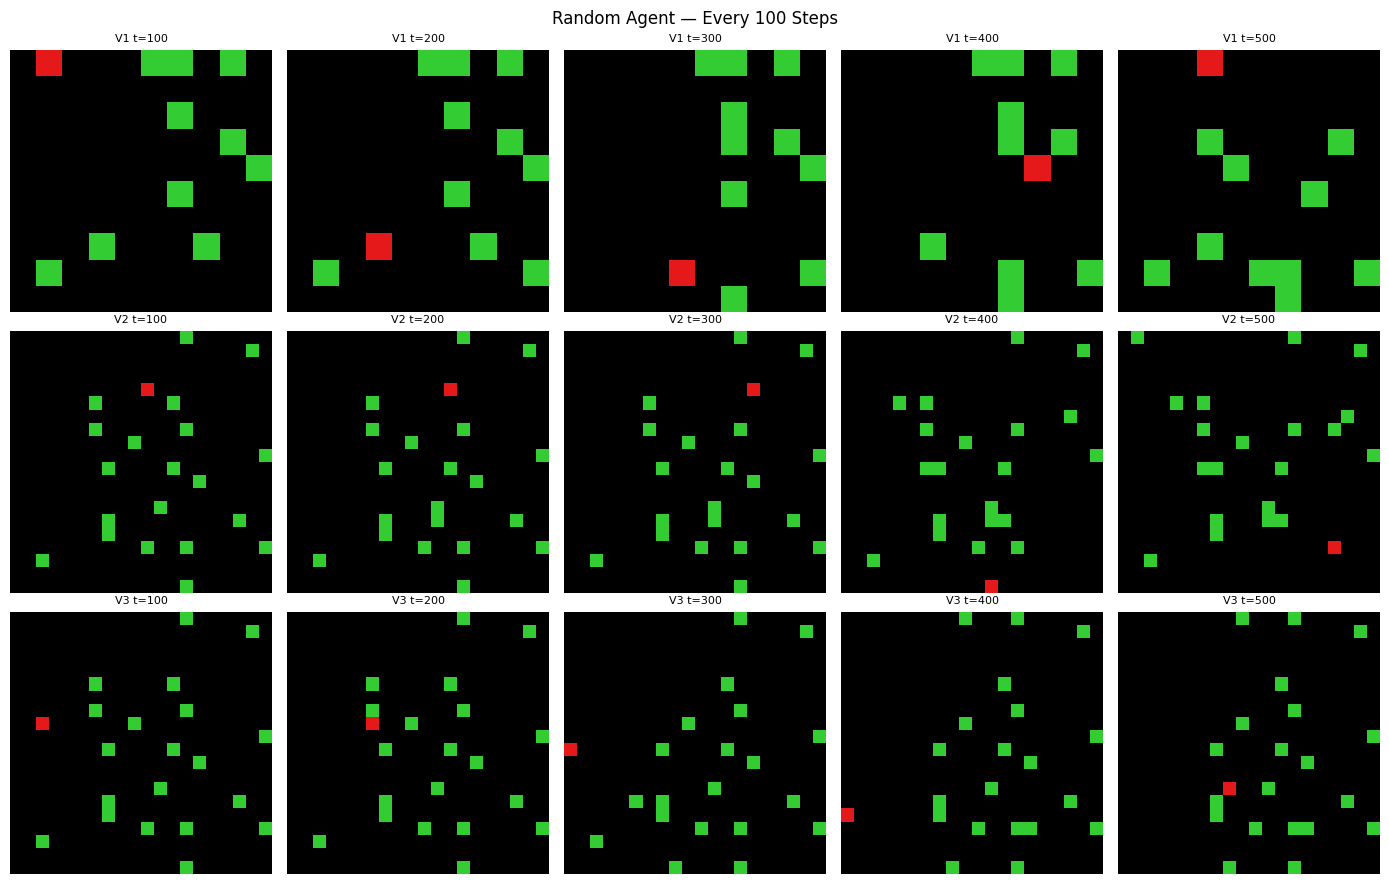

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(14, 9))

for row, name in enumerate(["V1", "V2", "V3"]):
    env = ForagingEnv.make(name, seed=0)
    obs = env.reset()
    done = False
    step_count = 0
    col = 0
    while not done and col < 5:
        obs, _, done, _ = env.step(np.random.randint(0, 4))
        if env.steps % 100 == 0:
            env.render(ax=axes[row][col])
            axes[row][col].set_title(
                f"{name} t={env.steps}", fontsize=8)
            col += 1

plt.suptitle("Random Agent — Every 100 Steps", fontsize=12)
plt.tight_layout()
plt.savefig("env_variants.png", dpi=150)
plt.show()